In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('data/public_transport_delays.csv')

# First look
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [6]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

Shape: (2000, 24)

Columns: ['trip_id', 'date', 'time', 'transport_type', 'route_id', 'origin_station', 'destination_station', 'scheduled_departure', 'scheduled_arrival', 'actual_departure_delay_min', 'actual_arrival_delay_min', 'weather_condition', 'temperature_C', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type', 'event_attendance_est', 'traffic_congestion_index', 'holiday', 'peak_hour', 'weekday', 'season', 'delayed']

Data types:
trip_id                           str
date                              str
time                              str
transport_type                    str
route_id                          str
origin_station                    str
destination_station               str
scheduled_departure               str
scheduled_arrival                 str
actual_departure_delay_min      int64
actual_arrival_delay_min        int64
weather_condition                 str
temperature_C                 float64
humidity_percent                int64
wind_spe

In [7]:
df.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


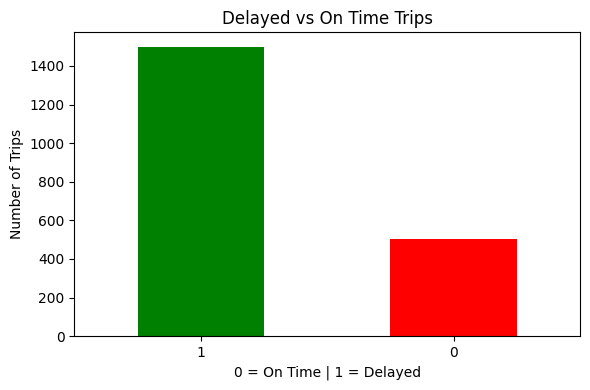

In [8]:
# How many trips were delayed vs on time?
plt.figure(figsize=(6, 4))
df['delayed'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Delayed vs On Time Trips')
plt.xlabel('0 = On Time | 1 = Delayed')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0) #dik durmasını sağlıyo
plt.tight_layout() #grafik elemanlarini düzgün hizalar
plt.show()

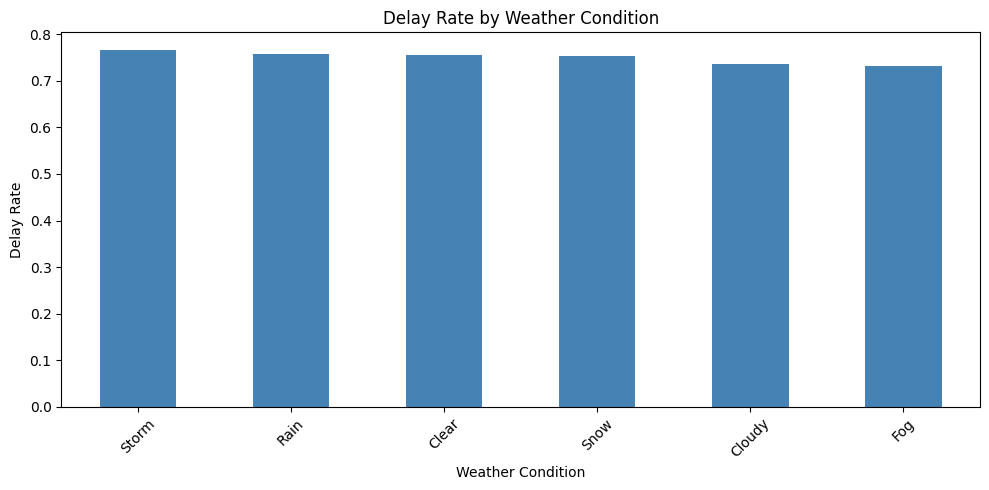

In [9]:
# Delay rate by weather condition
plt.figure(figsize=(10, 5)) # genislik: 10 inc, yükseklik: 5 inc
df.groupby('weather_condition')['delayed'].mean().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Delay Rate by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Delay Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

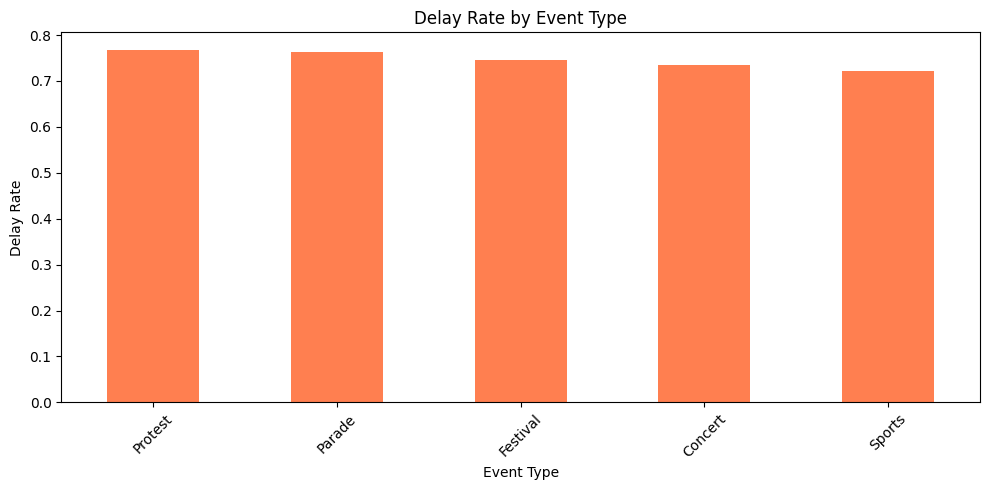

In [10]:
# Delay rate by event type
plt.figure(figsize=(10, 5))
df.groupby('event_type')['delayed'].mean().sort_values(ascending=False).plot(kind='bar', color='coral')
plt.title('Delay Rate by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Delay Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

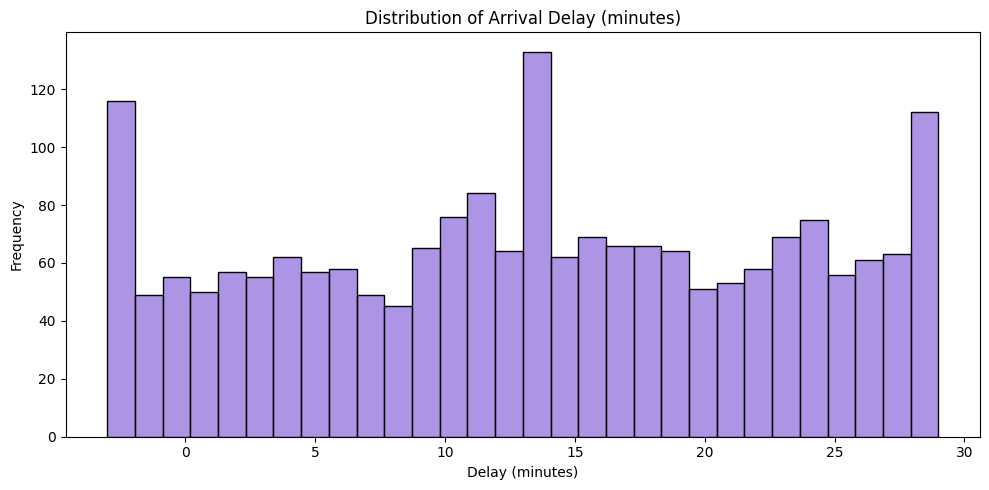

In [11]:
# Distribution of actual arrival delay
plt.figure(figsize=(10, 5))
sns.histplot(df['actual_arrival_delay_min'], bins=30, color='mediumpurple')
plt.title('Distribution of Arrival Delay (minutes)')
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

---
## Linear Regression Model — Predicting Arrival Delay

**Goal:** Predict `actual_arrival_delay_min` using weather, event, and traffic features.

### Step 1 — Preprocessing

In [12]:
# --- Step 1: Preprocessing ---

# Make a copy so we don't modify the original dataframe
df_model = df.copy()

# Fill missing event_type values — if there's no event, label it "No Event"
df_model['event_type'] = df_model['event_type'].fillna('No Event')

# One-hot encode categorical columns (drop_first=True avoids the "dummy variable trap")
# This converts e.g. season=[Winter, Summer] → season_Winter=1/0, season_Summer=1/0
df_model = pd.get_dummies(df_model, columns=['weather_condition', 'season', 'transport_type', 'event_type'], drop_first=True)

print("Preprocessing done!")
print(f"Dataset shape after encoding: {df_model.shape}")

Preprocessing done!
Dataset shape after encoding: (2000, 36)


### Step 2 — Feature & Target Selection

In [13]:
# --- Step 2: Feature & Target Selection ---

# Target variable: what we want to predict
y = df_model['actual_arrival_delay_min']

# Features: columns we drop because they are IDs, raw strings, or the target itself
drop_cols = [
    'trip_id',                      # just an ID, no predictive value
    'date', 'time',                 # raw strings (not parsed)
    'route_id',                     # high-cardinality ID
    'origin_station',               # high-cardinality string
    'destination_station',          # high-cardinality string
    'scheduled_departure',          # raw time string
    'scheduled_arrival',            # raw time string
    'actual_departure_delay_min',   # too directly related — would leak the answer
    'actual_arrival_delay_min',     # this IS our target
    'delayed',                      # derived from the target — would leak the answer
]

X = df_model.drop(columns=drop_cols)

print(f"Features (X): {X.shape[1]} columns")
print(f"Target  (y): {y.name}")
print("\nFeature columns:")
print(X.columns.tolist())

Features (X): 25 columns
Target  (y): actual_arrival_delay_min

Feature columns:
['temperature_C', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index', 'holiday', 'peak_hour', 'weekday', 'weather_condition_Cloudy', 'weather_condition_Fog', 'weather_condition_Rain', 'weather_condition_Snow', 'weather_condition_Storm', 'season_Spring', 'season_Summer', 'season_Winter', 'transport_type_Metro', 'transport_type_Train', 'transport_type_Tram', 'event_type_Festival', 'event_type_No Event', 'event_type_Parade', 'event_type_Protest', 'event_type_Sports']


### Step 3 — Train/Test Split

In [15]:
# --- Step 3: Train/Test Split ---
from sklearn.model_selection import train_test_split

# 80% training data, 20% test data
# random_state=42 makes the split reproducible (same result every run)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set:   {X_train.shape[0]} rows")
print(f"Test set:       {X_test.shape[0]} rows")
print(f"Total:          {X_train.shape[0] + X_test.shape[0]} rows")

Training set:   1600 rows
Test set:       400 rows
Total:          2000 rows


### Step 4 — Train the Model

In [16]:
# --- Step 4: Train the Model ---
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train it — the model learns the relationship between features and delay
model.fit(X_train, y_train)

# Use the trained model to predict delays on the test set
y_pred = model.predict(X_test)

print("Model trained successfully!")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Number of coefficients: {len(model.coef_)}")

Model trained successfully!
Intercept: 15.30
Number of coefficients: 25


### Step 5 — Evaluate the Model

| Metric | What it tells us |
|--------|-----------------|
| **MAE** (Mean Absolute Error) | Average error in minutes — easy to interpret |
| **MSE** (Mean Squared Error) | Penalizes large errors more heavily |
| **R²** (R-squared) | How much of the delay variance the model explains (1.0 = perfect) |

In [18]:
# --- Step 5: Evaluate the Model ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("=== Model Evaluation ===")
print(f"MAE  (Mean Absolute Error):  {mae:.2f} minutes")
print(f"MSE  (Mean Squared Error):   {mse:.2f}")
print(f"R²   (R-squared):            {r2:.4f}")
print()
if r2 < 0.2:
    print("The R² is low — the model captures some signal but delay is hard to predict from these features alone.")
elif r2 < 0.5:
    print("Moderate R² — the model explains part of the variance. There's room to improve.")
else:
    print("Good R² — the model explains a meaningful portion of delay variance.")

=== Model Evaluation ===
MAE  (Mean Absolute Error):  7.73 minutes
MSE  (Mean Squared Error):   85.64
R²   (R-squared):            -0.0157

The R² is low — the model captures some signal but delay is hard to predict from these features alone.


### Step 6 — Visualize: Actual vs Predicted

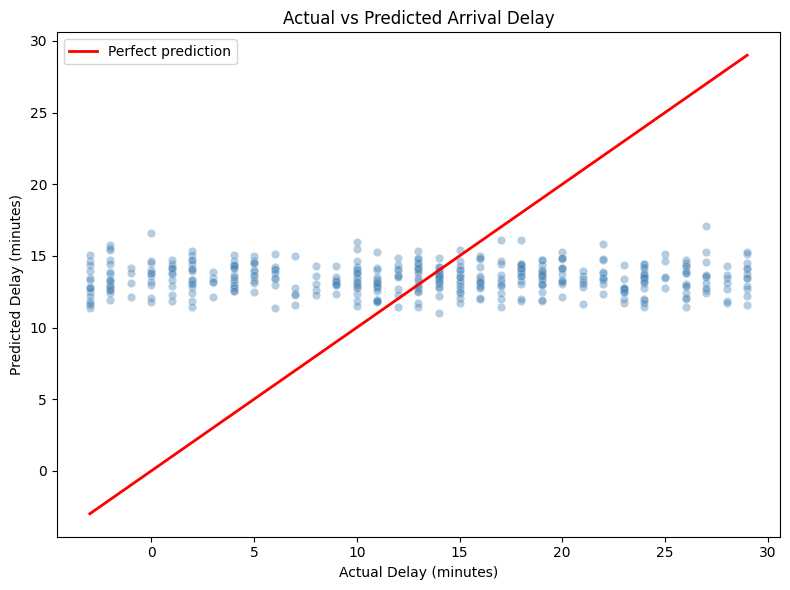

In [19]:
# --- Step 6: Actual vs Predicted Plot ---
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)

# Perfect prediction line — if all points lay on this, the model would be flawless
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Perfect prediction')

plt.title('Actual vs Predicted Arrival Delay')
plt.xlabel('Actual Delay (minutes)')
plt.ylabel('Predicted Delay (minutes)')
plt.legend()
plt.tight_layout()
plt.show()

### Step 7 — Feature Coefficients

A coefficient tells us: *"For every 1-unit increase in this feature, the predicted delay changes by this many minutes."*
- **Positive** coefficient → feature increases delay
- **Negative** coefficient → feature decreases delay

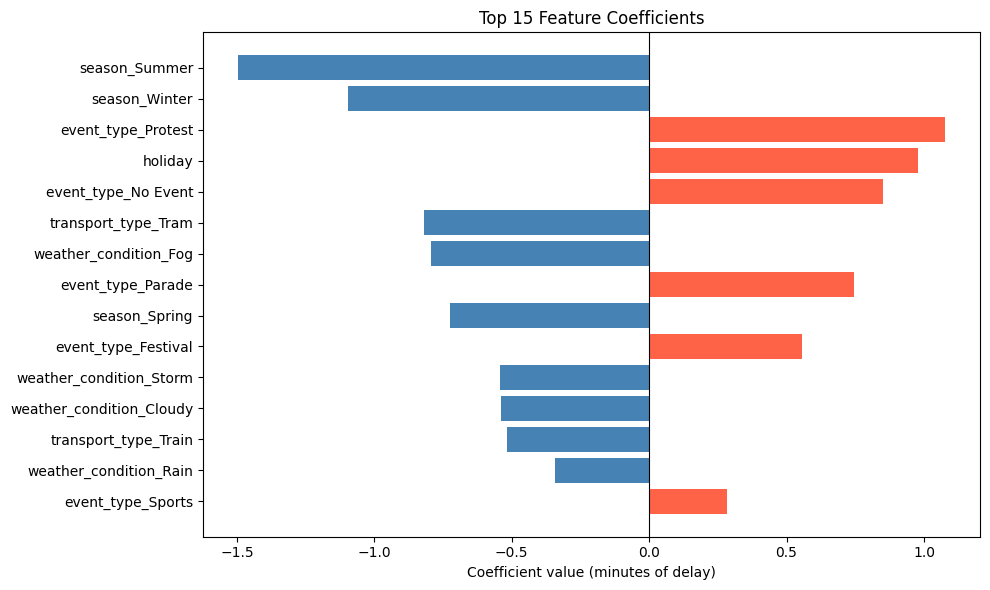


Full coefficient table:
                 Feature  Coefficient
           season_Summer    -1.494918
           season_Winter    -1.095565
      event_type_Protest     1.075379
                 holiday     0.977441
     event_type_No Event     0.849398
     transport_type_Tram    -0.820035
   weather_condition_Fog    -0.793867
       event_type_Parade     0.744167
           season_Spring    -0.725721
     event_type_Festival     0.556576
 weather_condition_Storm    -0.541514
weather_condition_Cloudy    -0.538060
    transport_type_Train    -0.517219
  weather_condition_Rain    -0.341801
       event_type_Sports     0.284170
               peak_hour     0.171270
  weather_condition_Snow    -0.128402
    transport_type_Metro    -0.121936
                 weekday    -0.045266
           temperature_C    -0.037621
        precipitation_mm     0.009707
        humidity_percent    -0.009110
          wind_speed_kmh    -0.002196
traffic_congestion_index    -0.000580
    event_attendance_est 

In [20]:
# --- Step 7: Feature Coefficients ---

# Pair each feature name with its learned coefficient
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)  # sort by absolute size

# Plot top 15 most influential features
top_n = 15
top_coef = coef_df.head(top_n)

colors = ['tomato' if c > 0 else 'steelblue' for c in top_coef['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(top_coef['Feature'], top_coef['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Top {top_n} Feature Coefficients')
plt.xlabel('Coefficient value (minutes of delay)')
plt.gca().invert_yaxis()  # largest bar on top
plt.tight_layout()
plt.show()

print("\nFull coefficient table:")
print(coef_df.to_string(index=False))